# Task-1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# square shape
shape = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0]
], dtype=float)

In [3]:
def show_transform(matrix, title="Transformation"):
    transformed = matrix @ shape

    plt.figure(figsize=(10, 4))

    # before transformation
    plt.subplot(1, 2, 1)
    plt.plot(shape[0], shape[1], marker="o")
    plt.axhline(0, color="black", linewidth=0.5)
    plt.axvline(0, color="black", linewidth=0.5)
    plt.axis("equal")
    plt.grid(True)
    plt.title("Before")

    # after transformation
    plt.subplot(1, 2, 2)
    plt.plot(transformed[0], transformed[1], marker="o")
    plt.axhline(0, color="black", linewidth=0.5)
    plt.axvline(0, color="black", linewidth=0.5)
    plt.axis("equal")
    plt.grid(True)
    plt.title(title)

    plt.show()

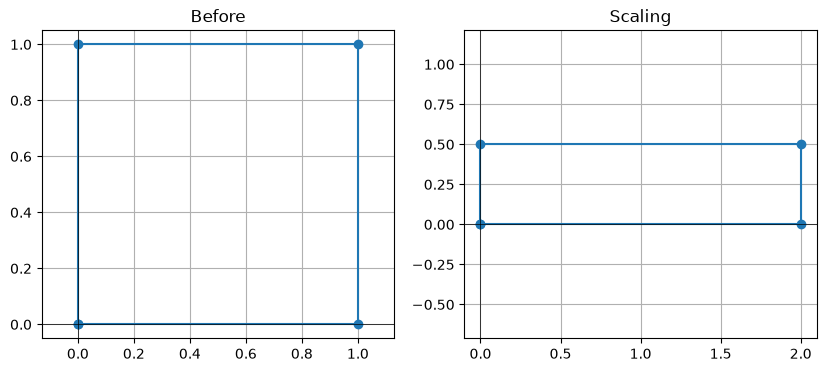

In [4]:
# scaling transformation
S = np.array([
    [2, 0],
    [0, 0.5]
])

show_transform(S, "Scaling")

In [5]:
# rotation transformation
def rotation(deg):
    theta = np.radians(deg)

    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

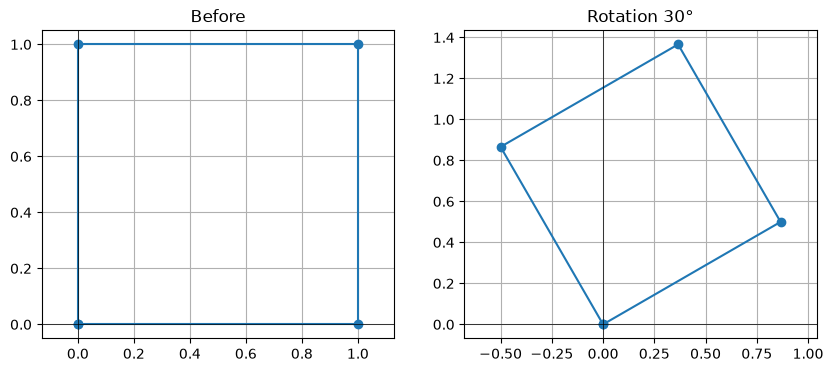

In [6]:
show_transform(rotation(30), "Rotation 30°")

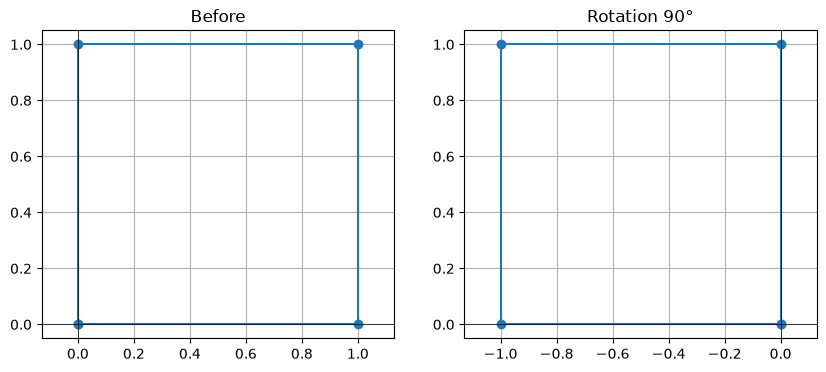

In [7]:
show_transform(rotation(90), "Rotation 90°")

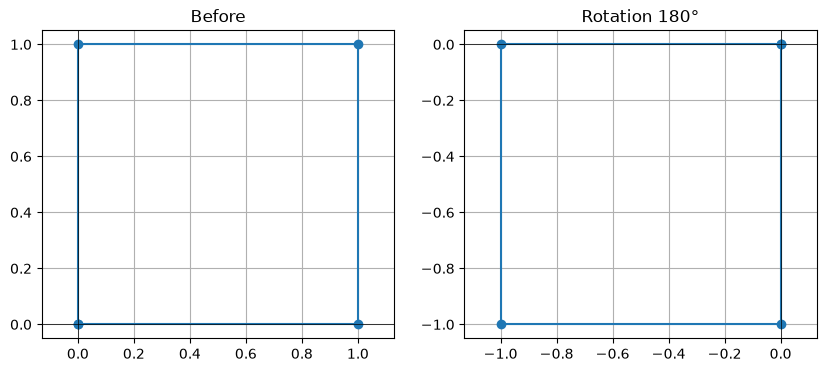

In [8]:
show_transform(rotation(180), "Rotation 180°")

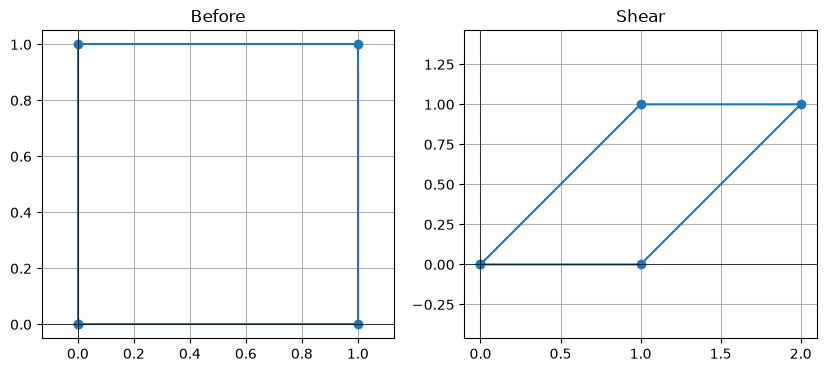

In [9]:
# shear transformation
Sh = np.array([
    [1, 1],
    [0, 1]
])

show_transform(Sh, "Shear")

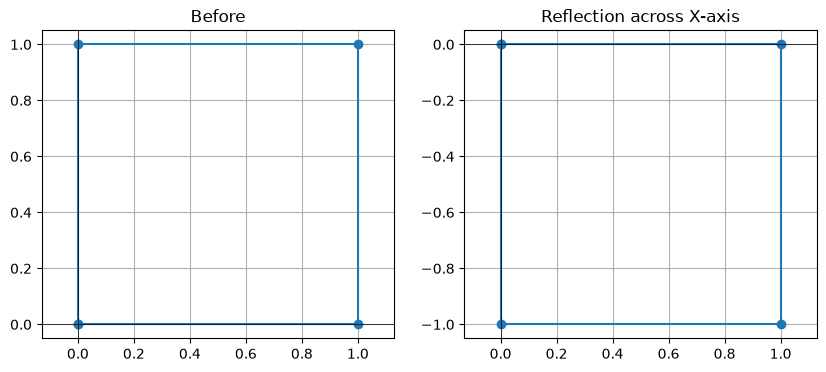

In [10]:
# reflection transformation following the X-axis
Rx = np.array([
    [1, 0],
    [0, -1]
])

show_transform(Rx, "Reflection across X-axis")

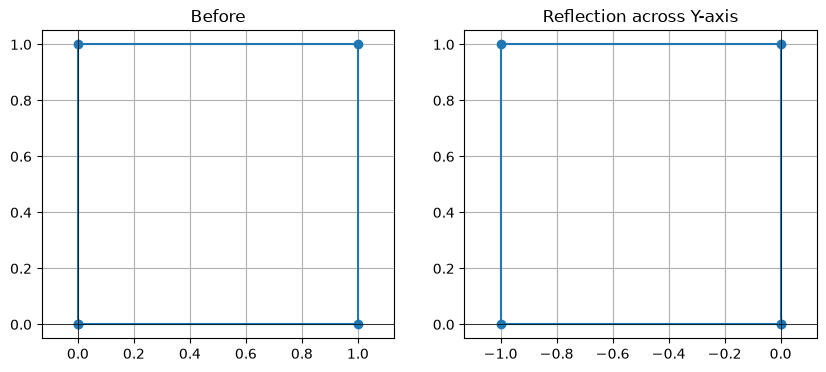

In [11]:
# reflection transformation following the Y-axis
Ry = np.array([
    [-1, 0],
    [0, 1]
])

show_transform(Ry, "Reflection across Y-axis")

In [12]:
#scaling: the x-axis is stretched and the y-axis is squished, while the origin stays fixed.
#rotation: the shape rotates around the origin while its size and shape stay unchanged.
#shear: the square becomes a parallelogram because points are shifted horizontally according to their y-coordinate.
#reflection: the shape flips across the selected axis while its size and shape remain unchanged.

# Task-2

In [13]:
# determinants of the transformation matrices
S = np.array([
    [2, 0],
    [0, 0.5]
])

print("scaling determinant:", np.linalg.det(S))

scaling determinant: 1.0


In [14]:
#rotation determinant
R = rotation(30)
print("rotation determinant:", np.linalg.det(R))

rotation determinant: 1.0


In [15]:
Sh = np.array([
    [1, 1],
    [0, 1]
])

print("shear determinant:", np.linalg.det(Sh))

shear determinant: 1.0


In [16]:
Rx = np.array([
    [1, 0],
    [0, -1]
])

Ry = np.array([
    [-1, 0],
    [0, 1]
])

print("X-axis reflection:", np.linalg.det(Rx))
print("Y-axis reflection:", np.linalg.det(Ry))

X-axis reflection: -1.0
Y-axis reflection: -1.0


In [17]:
sing = np.array([
    [1., 2.],
    [2., 4.]
])

print("singular matrix:")
print(sing)

print("determinant:", np.linalg.det(sing))

singular matrix:
[[1. 2.]
 [2. 4.]]
determinant: 0.0


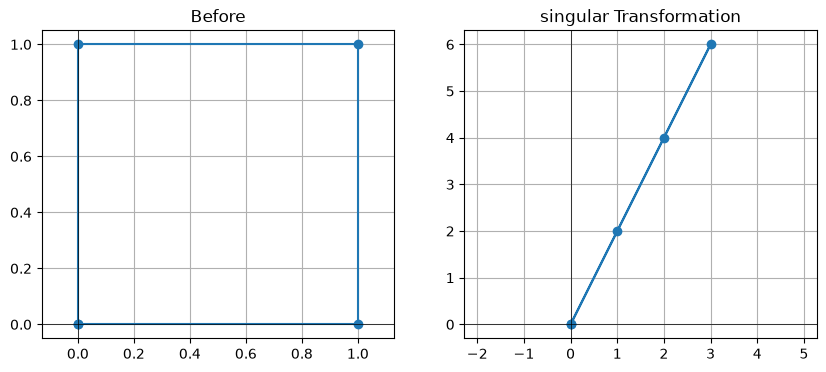

In [18]:
show_transform(sing, "singular Transformation")

In [19]:
try:
    inverse = np.linalg.inv(sing)
    print(inverse)
except np.linalg.LinAlgError as e:
    print("Error:", e)

Error: Singular matrix


In [20]:
def is_invertible(matrix):
    det = np.linalg.det(matrix)
    return not np.isclose(det, 0)

In [21]:
print("scaling:", is_invertible(S))
print("rotation:", is_invertible(R))
print("shear:", is_invertible(Sh))
print("reflection:", is_invertible(Rx))
print("singular:", is_invertible(sing))

scaling: True
rotation: True
shear: True
reflection: True
singular: False


In [22]:
# a determinant of zero means the transformation loses information
# by collapsing the shape into a lower dimension, so it cannot be undone.

# Task-3

In [23]:
A = rotation(30)

B = np.array([
    [2, 0],
    [0, 1]
], dtype=float)

C = np.array([
    [1, 1],
    [0, 1]
], dtype=float)

print("A =\n", A)
print("B =\n", B)
print("C =\n", C)

A =
 [[ 0.8660254 -0.5      ]
 [ 0.5        0.8660254]]
B =
 [[2. 0.]
 [0. 1.]]
C =
 [[1. 1.]
 [0. 1.]]


In [24]:
# compute (AB)C
left = (A @ B) @ C

print("(AB)C =")
print(left)

(AB)C =
[[1.73205081 1.23205081]
 [1.         1.8660254 ]]


In [25]:
# compute A(BC)
right = A @ (B @ C)

print("A(BC) =")
print(right)

A(BC) =
[[1.73205081 1.23205081]
 [1.         1.8660254 ]]


In [26]:
# check if (AB)C is equal to A(BC)
print("Associative:", np.allclose(left, right))

Associative: True


In [27]:
# check if A @ B is equal to B @ A
AB = A @ B
BA = B @ A

print("A @ B =")
print(AB)

print("\nB @ A =")
print(BA)

print("\nCommutative:", np.allclose(AB, BA))

A @ B =
[[ 1.73205081 -0.5       ]
 [ 1.          0.8660254 ]]

B @ A =
[[ 1.73205081 -1.        ]
 [ 0.5         0.8660254 ]]

Commutative: False


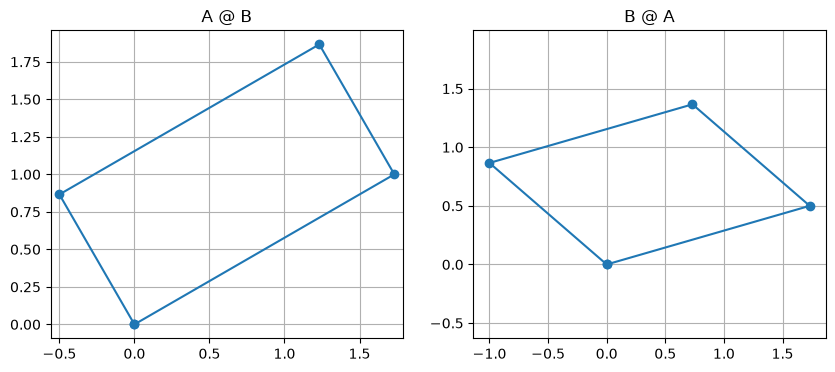

In [28]:
shape_AB = (A @ B) @ shape
shape_BA = (B @ A) @ shape

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(shape_AB[0], shape_AB[1], marker="o")
plt.axis("equal")
plt.grid(True)
plt.title("A @ B")

plt.subplot(1, 2, 2)
plt.plot(shape_BA[0], shape_BA[1], marker="o")
plt.axis("equal")
plt.grid(True)
plt.title("B @ A")

plt.show()

In [29]:
#associativity: grouping does not matter. (AB)C = A(BC)
#commutativity: Order generally matters. AB ≠ BA
#for transformations, the matrix closest to the shape acts first.

# Task-4

In [30]:
# scaling
S = np.array([
    [1.5, 0],
    [0, 1.5]
], dtype=float)

# rotation
R = rotation(45)

# shear
Sh = np.array([
    [1, 0.5],
    [0, 1]
], dtype=float)

In [31]:
# apply transformations in different orders
stage1 = S @ shape
stage2 = R @ stage1
stage3 = Sh @ stage2

In [32]:
# show the final result after applying the transformations in the order S -> R -> Sh
combined = Sh @ R @ S

print("Combined matrix:")
print(combined)

Combined matrix:
[[ 1.59099026 -0.53033009]
 [ 1.06066017  1.06066017]]


In [33]:
# verify that the transformations produce the same result
separate = Sh @ R @ S @ shape
one_step = combined @ shape

print("Same result:", np.allclose(separate, one_step))

Same result: True


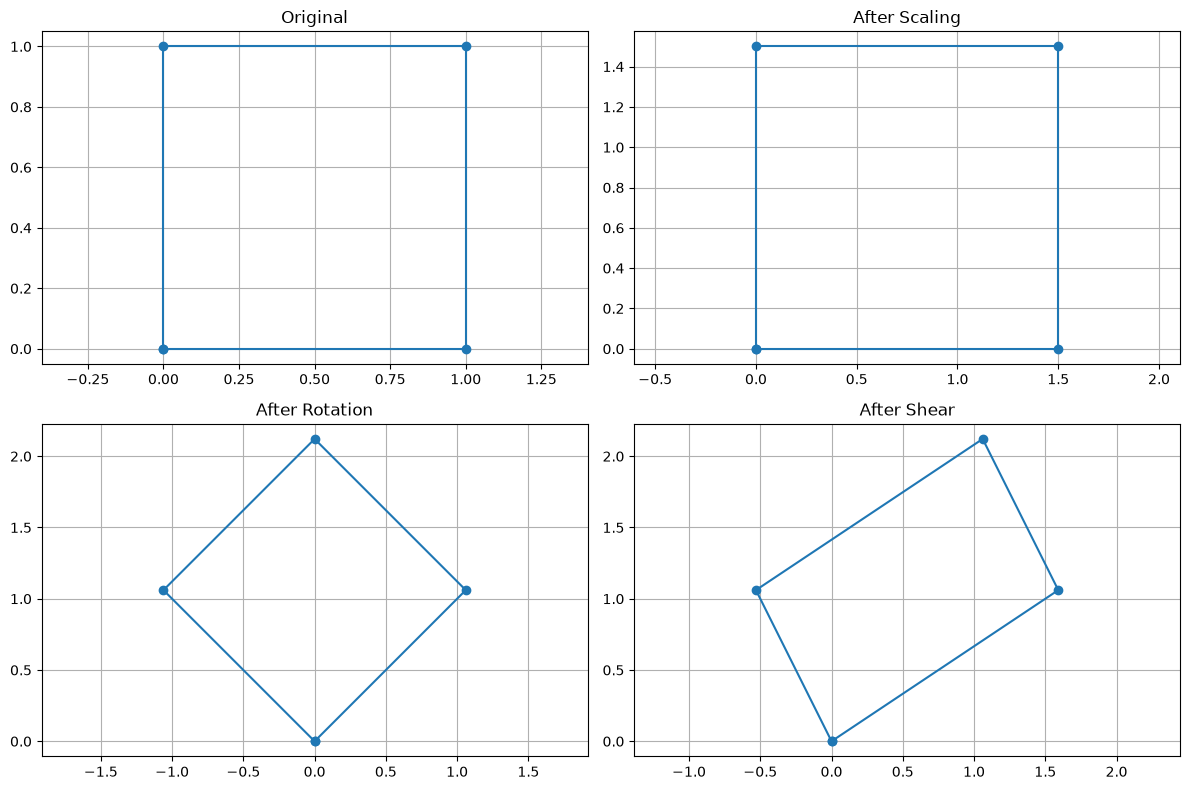

In [34]:
# visualize the transformations
plt.figure(figsize=(12, 8))

# original
plt.subplot(2, 2, 1)
plt.plot(shape[0], shape[1], marker="o")
plt.axis("equal")
plt.grid(True)
plt.title("Original")

# after scaling
plt.subplot(2, 2, 2)
plt.plot(stage1[0], stage1[1], marker="o")
plt.axis("equal")
plt.grid(True)
plt.title("After Scaling")

# after rotation
plt.subplot(2, 2, 3)
plt.plot(stage2[0], stage2[1], marker="o")
plt.axis("equal")
plt.grid(True)
plt.title("After Rotation")

# after shear
plt.subplot(2, 2, 4)
plt.plot(stage3[0], stage3[1], marker="o")
plt.axis("equal")
plt.grid(True)
plt.title("After Shear")

plt.tight_layout()
plt.show()

In [35]:
# determinants of the transformation matrices
det_S = np.linalg.det(S)
det_R = np.linalg.det(R)
det_Sh = np.linalg.det(Sh)

det_combined = np.linalg.det(combined)

print("det(S) =", det_S)
print("det(R) =", det_R)
print("det(Sh) =", det_Sh)
print("det(combined) =", det_combined)

print(
    "Product of determinants =",
    det_S * det_R * det_Sh
)

det(S) = 2.25
det(R) = 1.0
det(Sh) = 1.0
det(combined) = 2.2500000000000004
Product of determinants = 2.25


In [36]:
# check if the determinant of the combined matrix equals the product of the individual determinants
print("Determinants match:",np.isclose(det_combined, det_S * det_R * det_Sh))

Determinants match: True


In [37]:
#the transformations are combined as Sh @ R @ S because the first transformation is placed on the right.
#applying the combined matrix gives the same result as applying the three transformations separately.
#the determinant of the combined matrix equals the product of the individual determinants.

# Task-5

In [38]:
# Check if a matrix is diagonal
D = np.array([
    [2, 0],
    [0, 3]
], dtype=float)

print("diagonal matrix:")
print(D)

print("diagonal or not:", np.allclose(D, np.diag(np.diag(D))))

diagonal matrix:
[[2. 0.]
 [0. 3.]]
diagonal or not: True


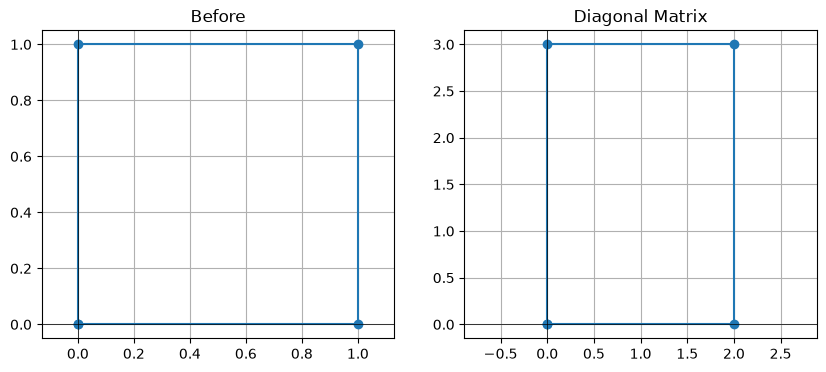

In [39]:
# show the transformation of the diagonal matrix
show_transform(D, "Diagonal Matrix")

In [40]:
# check if a matrix is symmetric
sym = np.array([
    [2., 1.],
    [1., 3.]
])

print("Symmetric matrix:")
print(sym)

print("Transpose:")
print(sym.T)

print("symmetric or not:", np.allclose(sym, sym.T))

Symmetric matrix:
[[2. 1.]
 [1. 3.]]
Transpose:
[[2. 1.]
 [1. 3.]]
symmetric or not: True


In [41]:
# check if a matrix is orthogonal
Q = rotation(30)

print("Rotation matrix:")
print(Q)

print("Q.T @ Q:")
print(Q.T @ Q)

print("Identity matrix:")
print(np.eye(2))

print("orthogonal or not:", np.allclose(Q.T @ Q, np.eye(2)))

Rotation matrix:
[[ 0.8660254 -0.5      ]
 [ 0.5        0.8660254]]
Q.T @ Q:
[[1.00000000e+00 7.43708407e-18]
 [7.43708407e-18 1.00000000e+00]]
Identity matrix:
[[1. 0.]
 [0. 1.]]
orthogonal or not: True


In [42]:
# check if a matrix preserves length
v = np.array([3., 4.])

original_length = np.linalg.norm(v)
new_length = np.linalg.norm(Q @ v)

print("original length:", original_length)
print("new length:", new_length)

print("length preserved:",np.isclose(original_length, new_length))

original length: 5.0
new length: 5.0
length preserved: True


In [43]:
# Check if a matrix preserves angles
v1 = np.array([1., 0.])
v2 = np.array([1., 1.])

def angle_between(a, b):
    cosine = np.dot(a, b) / (
        np.linalg.norm(a) * np.linalg.norm(b)
    )
    return np.degrees(np.arccos(np.clip(cosine, -1, 1)))

original_angle = angle_between(v1, v2)

v1_rotated = Q @ v1
v2_rotated = Q @ v2

new_angle = angle_between(v1_rotated, v2_rotated)

print("original angle:", original_angle)
print("new angle:", new_angle)

print("angle preserved:", np.isclose(original_angle, new_angle))


original angle: 45.00000000000001
new angle: 45.00000000000001
angle preserved: True


In [44]:
# rotations and reflections preserve lengths and angles,
# so they are orthogonal matrices.
# scaling and shear change lengths or angles, so they are not orthogonal.

# Task-6

In [45]:
# explore the effect of a 2x2 matrix on a shape
def explore(a, b, c, d):
    # Create the 2x2 matrix
    M = np.array([
        [a, b],
        [c, d]
    ], dtype=float)

    # apply transformation
    transformed = M @ shape

    # determinant
    det = np.linalg.det(M)

    # basis vectors
    e1 = M[:, 0]
    e2 = M[:, 1]

    print("Matrix:")
    print(M)

    print("\nBasis vectors:")
    print("e1 =", e1)
    print("e2 =", e2)

    print("\nDeterminant:", det)

    # plot
    plt.figure(figsize=(10, 5))

    # before
    plt.subplot(1, 2, 1)
    plt.plot(shape[0], shape[1], marker="o")
    plt.axhline(0, linewidth=0.5)
    plt.axvline(0, linewidth=0.5)
    plt.axis("equal")
    plt.grid(True)
    plt.title("Before")

    # after
    plt.subplot(1, 2, 2)
    plt.plot(transformed[0], transformed[1], marker="o")

    # draw transformed basis vectors
    plt.arrow(
        0, 0, e1[0], e1[1],
        head_width=0.08,
        length_includes_head=True
    )

    plt.arrow(
        0, 0, e2[0], e2[1],
        head_width=0.08,
        length_includes_head=True
    )

    plt.axhline(0, linewidth=0.5)
    plt.axvline(0, linewidth=0.5)
    plt.axis("equal")
    plt.grid(True)
    plt.title(f"After | det = {det:.2f}")

    plt.show()

Matrix:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Basis vectors:
e1 = [0.70710678 0.70710678]
e2 = [-0.70710678  0.70710678]

Determinant: 1.0


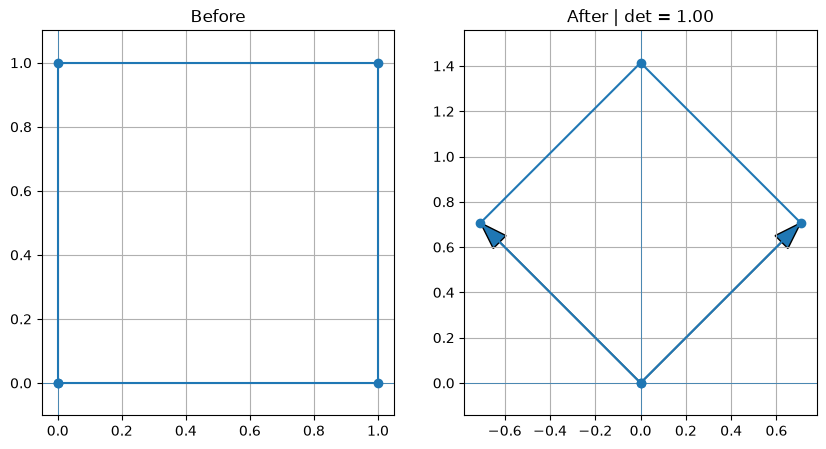

In [46]:
# explore the effect of a 2x2 matrix on a shape
R = rotation(45)

explore(
    R[0, 0],
    R[0, 1],
    R[1, 0],
    R[1, 1]
)

Matrix:
[[2. 0.]
 [0. 3.]]

Basis vectors:
e1 = [2. 0.]
e2 = [0. 3.]

Determinant: 6.0


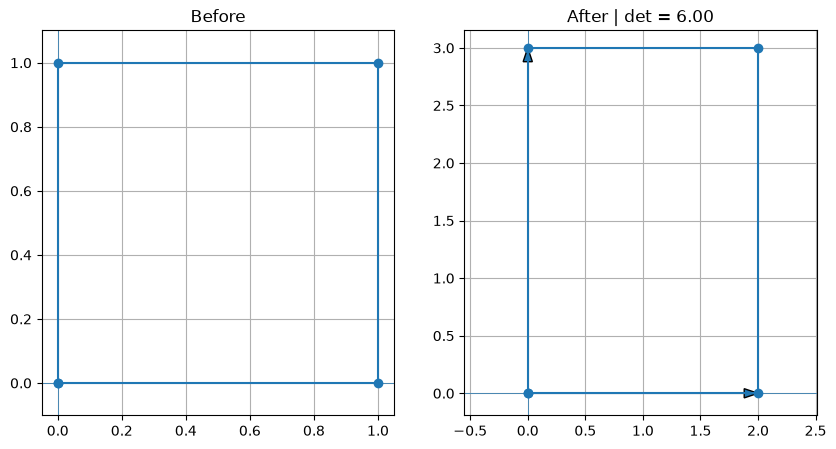

In [47]:
# explore the effect of a 2x2 matrix on a shape
explore(2, 0, 0, 3)

Matrix:
[[ 1.  0.]
 [ 0. -1.]]

Basis vectors:
e1 = [1. 0.]
e2 = [ 0. -1.]

Determinant: -1.0


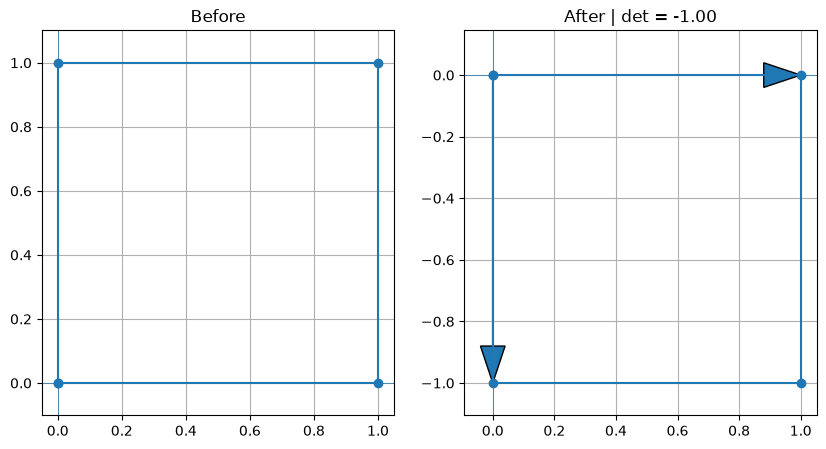

In [48]:
# Explore the effect of a 2x2 matrix on a shape
explore(1, 0, 0, -1)

Matrix:
[[1. 2.]
 [2. 4.]]

Basis vectors:
e1 = [1. 2.]
e2 = [2. 4.]

Determinant: 0.0


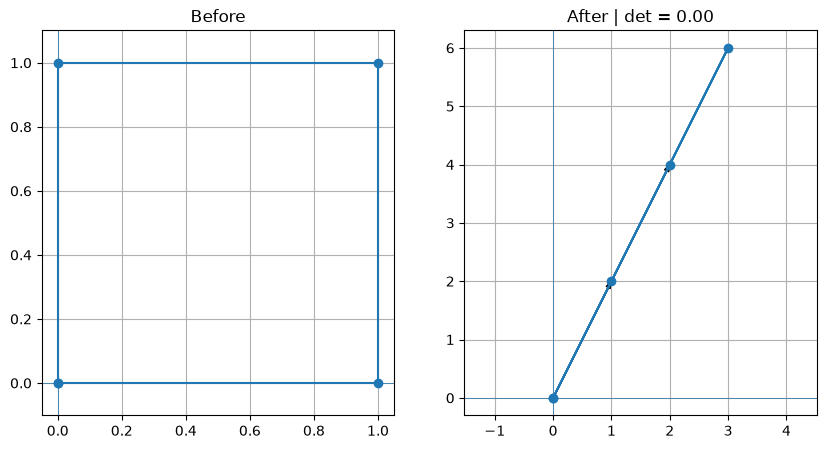

In [ ]:
# Explore the effect of a 2x2 matrix on a shape
explore(1, 2, 2, 4)

In [50]:
# reference of 2x2 matrices and their effects
reference = [
    ["identity", [[1, 0], [0, 1]], "No change", 1],
    ["scaling", [[2, 0], [0, 3]], "Stretches", 6],
    ["rotation", rotation(45), "Rotates", 1],
    ["reflection", [[1, 0], [0, -1]], "Flips", -1],
    ["singular", [[1, 2], [2, 4]], "Collapses to line", 0]
]

for name, matrix, effect, det in reference:
    print(f"{name:12} | Effect: {effect:18} | Determinant: {det}")

identity     | Effect: No change          | Determinant: 1
scaling      | Effect: Stretches          | Determinant: 6
rotation     | Effect: Rotates            | Determinant: 1
reflection   | Effect: Flips              | Determinant: -1
singular     | Effect: Collapses to line  | Determinant: 0
